# Diffusion Model

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from implied_volatility_diffusion import SurfaceNormalizer, UnifiedGrid, VPNoiseScheduler
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    build_historical_surface_pipeline,
    load_cleaned_data,
)

In [7]:
repo_root = Path.cwd().resolve()
for _candidate in (repo_root, *repo_root.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        repo_root = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")

config_path = repo_root / "config" / "unified_iv_grid.yaml"
processed_path = repo_root / "data" / "processed" / "processed.parquet"

if str(repo_root / "notebooks") not in sys.path:
    sys.path.insert(0, str(repo_root / "notebooks"))
from plot_style import SURF_CMAP, apply_theme, style_2d_axes

PLOT_THEME = "plotnine"
apply_theme(PLOT_THEME)

In [8]:
grid = UnifiedGrid.load(config_path)
scheduler = VPNoiseScheduler(timesteps=2000, beta_schedule="linear", beta=1.0)
k_mesh, tau_mesh = np.meshgrid(grid.log_moneyness, grid.tau, indexing="ij")

In [9]:
# historical IV surface on the same unified grid, then normalize it.
df = load_cleaned_data(processed_path)

normalizer = SurfaceNormalizer(grid_shape=grid.shape)
for quote_date, day_quotes in df.groupby("quote_date", sort=True):
    day_stage = build_historical_surface_pipeline(
        day_quotes,
        sample_date=pd.Timestamp(quote_date),
        unified_grid=grid,
    )
    normalizer.partial_fit(day_stage.iv_unified)

sample_date = pd.Timestamp("2021-06-17")
day_df = df[df["quote_date"] == sample_date].copy()
if day_df.empty:
    raise ValueError(f"No rows found for {sample_date.date()}")

historical_stage = build_historical_surface_pipeline(
    day_df,
    sample_date=sample_date,
    unified_grid=grid,
    normalizer=normalizer,
)

historical_iv = historical_stage.iv_unified
historical_clean = historical_stage.iv_normalized

/Users/sbonelomdluli/Desktop/ivs-vit/src/implied_volatility_diffusion/core/normalization.py:103: RuntimeWarning: invalid value encountered in divide
  var = np.where(self.count > 1, self._m2 / (self.count - 1), np.nan)


## VP Noise Scheduler Diagnostics


Visual check for large-$T$ behavior of the closed-form forward process:

\begin{equation}
X_t = \alpha_t X_0 + \sigma_t Z, \quad \alpha_t = e^{-\beta t / 2}, \quad \sigma_t = \sqrt{1 - e^{-\beta t}}, \quad Z \sim \mathcal{N}(0,1).
\end{equation}

As $t \to \infty$, the distribution of $X_t$ converges to $\mathcal{N}(0,1)$.

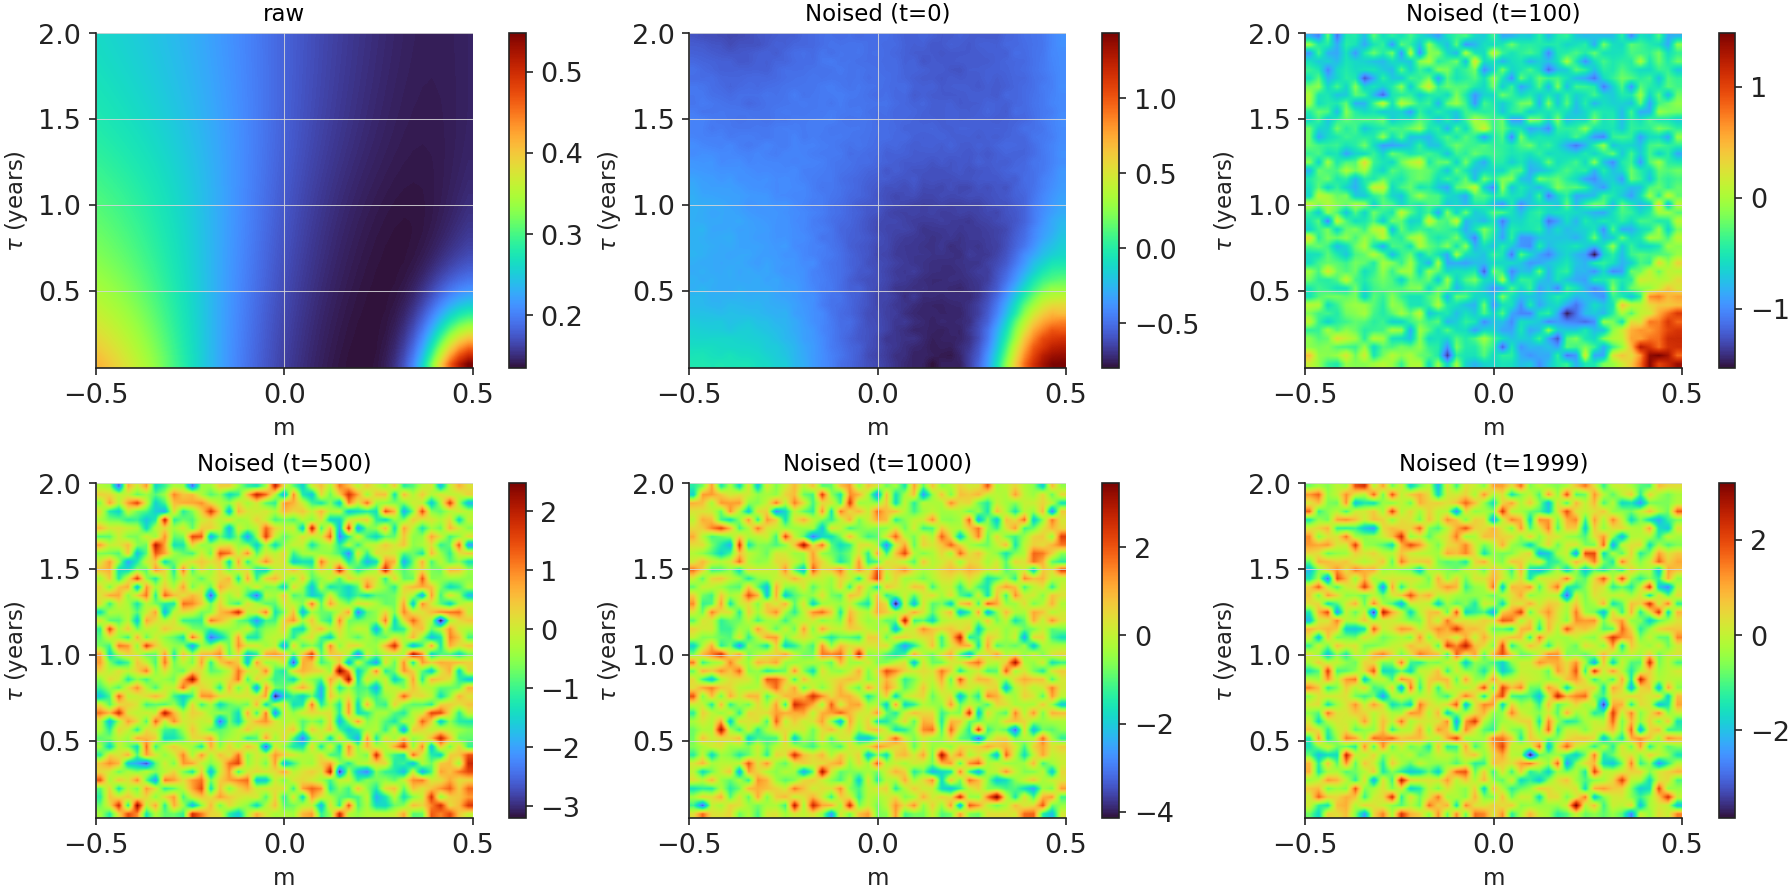

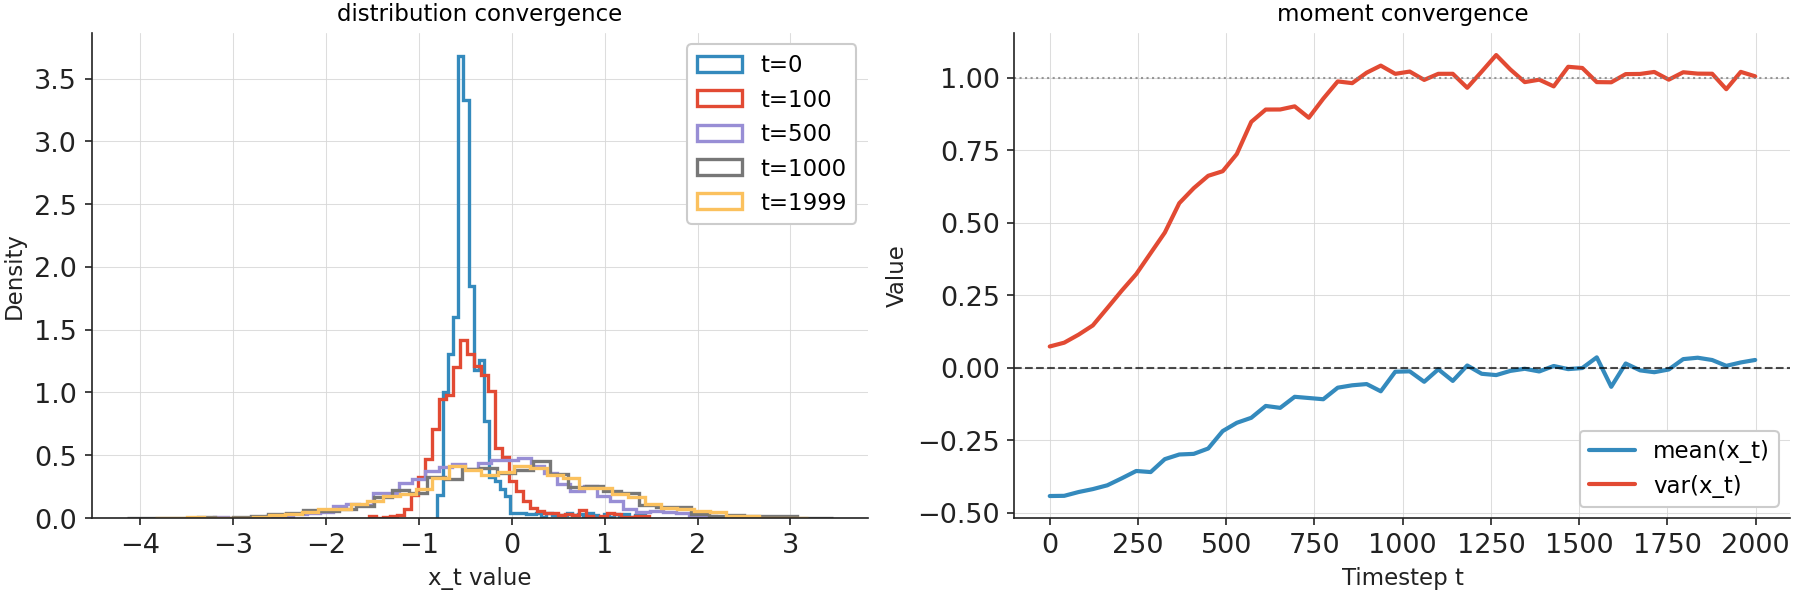

In [11]:
# diagnosticc
seed = 123
surface_img = torch.tensor(historical_clean, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

t_values = torch.tensor([0, 100, 500, 1000, 1999], dtype=torch.long)
t_values = torch.clamp(t_values, max=scheduler.timesteps - 1)
progression = (
    scheduler.forward_process(
        surface_img,
        t_values,
        generator=torch.Generator().manual_seed(seed),
    )
    .squeeze(1)
    .squeeze(1)
    .numpy()
)


t_curve = torch.linspace(0, scheduler.timesteps - 1, steps=50).round().long().unique()
curve_samples = (
    scheduler.forward_process(
        surface_img,
        t_curve,
        generator=torch.Generator().manual_seed(seed + 1),
    )
    .squeeze(1)
    .squeeze(1)
    .numpy()
)

if "SURF_CMAP" not in globals() or "style_2d_axes" not in globals():
    import sys

    if str(repo_root / "notebooks") not in sys.path:
        sys.path.insert(0, str(repo_root / "notebooks"))
    from plot_style import SURF_CMAP, apply_theme, style_2d_axes

    PLOT_THEME = "plotnine"
    apply_theme(PLOT_THEME)

flat_curve = curve_samples.reshape(curve_samples.shape[0], -1)
means = flat_curve.mean(axis=1)
variances = flat_curve.var(axis=1)

m_axis = np.asarray(grid.log_moneyness, dtype=np.float64)
tau_axis = grid.tau
surface_extent = (m_axis[0], m_axis[-1], tau_axis[0], tau_axis[-1])


def plot_grid_surface(ax, values, *, cmap):
    image = ax.imshow(
        values.T,
        origin="lower",
        aspect="auto",
        extent=surface_extent,
        cmap=cmap,
        interpolation="bilinear",
    )
    ax.set_xlabel("m")
    ax.set_ylabel(r"$\tau$ (years)")
    style_2d_axes(ax)
    return image


fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])
axes = axes.flatten()

im0 = plot_grid_surface(axes[0], historical_iv, cmap=SURF_CMAP)
axes[0].set_title("raw")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

for i, t in enumerate(t_values.tolist(), start=1):
    im = plot_grid_surface(axes[i], progression[i - 1], cmap=SURF_CMAP)
    axes[i].set_title(f"Noised (t={t})")
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)


fig.savefig("historical_surface_progression.pdf", format="pdf", bbox_inches="tight")
plt.show()

fig_conv, (ax_dist, ax_mom) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_conv.patch.set_facecolor(plt.rcParams["figure.facecolor"])

for idx, t in enumerate(t_values.tolist()):
    x_t = progression[idx].ravel()
    ax_dist.hist(x_t, bins=40, density=True, histtype="step", linewidth=1.6, label=f"t={t}")
ax_dist.set_title("distribution convergence")
ax_dist.set_xlabel("x_t value")
ax_dist.set_ylabel("Density")
ax_dist.legend()
style_2d_axes(ax_dist)

t_axis = t_curve.cpu().numpy()
ax_mom.plot(t_axis, means, label="mean(x_t)", linewidth=2.0)
ax_mom.plot(t_axis, variances, label="var(x_t)", linewidth=2.0)
ax_mom.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
ax_mom.axhline(1.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.8)
ax_mom.set_title("moment convergence")
ax_mom.set_xlabel("Timestep t")
ax_mom.set_ylabel("Value")
ax_mom.legend()
style_2d_axes(ax_mom)


fig_conv.savefig("historical_convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()